In [1]:
import numpy as np
import astropy.units as u
import matplotlib.pyplot as plt

from numpy import trapezoid
from scipy.optimize import curve_fit
from scipy.interpolate import LinearNDInterpolator, NearestNDInterpolator

In [2]:
eta_0 = 0.313
_eta = ["1.1", "1.2", "1.3", "1.4", "1.5", "1.6", "1.7", "1.8", "1.9", "2.0", "3.0", "4.0", 
       "5.0", "6.0", "7.0", "8.0", "9.0", "10.0", "20.0", "30.0", "40.0", "100.0"]

In [3]:
def F(x, A, B, C, D, E):
    return A*np.pow(E,(x-B)*C)+D

In [4]:
def plot_fit_single(particle, eta, theta):
    fig, ax = plt.subplots(1,1,figsize = (8, 4))

    ax.set_title(rf"$\eta$ = {eta} $\eta_{0}$,  $\theta$ = {theta}$\degree$")

    interp_file = (
        f"./integrand_values/{particle}/{particle}_{eta}eta0_{theta}theta.txt"
    )

    x_i, spectrum = np.genfromtxt(
        interp_file, dtype="float", comments="#", usecols=(0, 1), unpack="True"
    )
    x_i = np.log10(np.where(x_i>0,x_i,1e-100))
    spectrum = np.log10(np.where(spectrum>0,spectrum,1e-100))

    ax.plot(x_i,spectrum,lw=2,label=r"SOPHIA")

    mask = (x_i >= -3) & (x_i <= 0)

    x_fit = x_i[mask]
    y_fit = spectrum[mask]

    count = 0
    for ii in range(0,6):
        if(y_fit[len(y_fit)-ii-1] < -50.):
            count=count+1
    if count!=0:
        x_fit = x_fit[:-count]
        y_fit = y_fit[:-count]

    # popt, pcov = curve_fit(F, x_fit, y_fit)
    popt, pcov = curve_fit(F, x_fit, y_fit, bounds=([-40,0.1,0.1,-40.,17],
                                                    [-12,0.6,4.5,-12.,20]))
    print(popt)

    F_i = np.append(F(x_i, *popt),-100.)
    x_i = np.append(x_i,0.)

    ax.plot(x_i, F_i,lw=2,label=r"Fit")

    ax.set_xlabel("x")
    ax.set_ylabel("f")

    # ax.set_xlim(1e-4,1)
    # ax.set_ylim(1e-21,1e-14)
    ax.set_ylim(-21,-14)

[-18.7356609    0.3731873    1.07747751 -17.03430795  18.52319218]
[-16.30065867   0.45514656   0.88183541 -16.31112618  18.19541448]
[-31.8843669    0.2511936    1.46256135 -16.19810012  17.9238716 ]
[-28.8032826    0.30361334   1.31839197 -16.12951594  17.82895235]


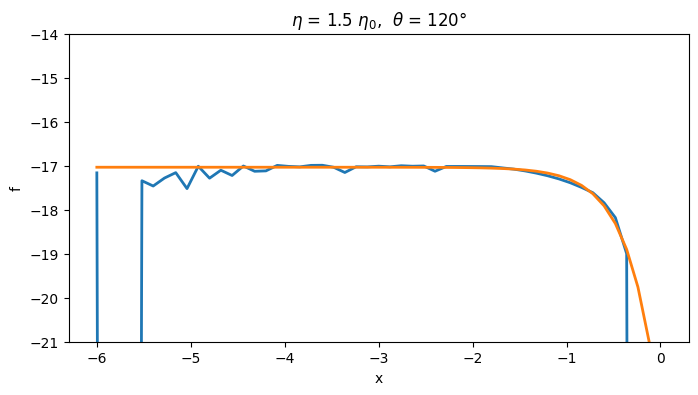

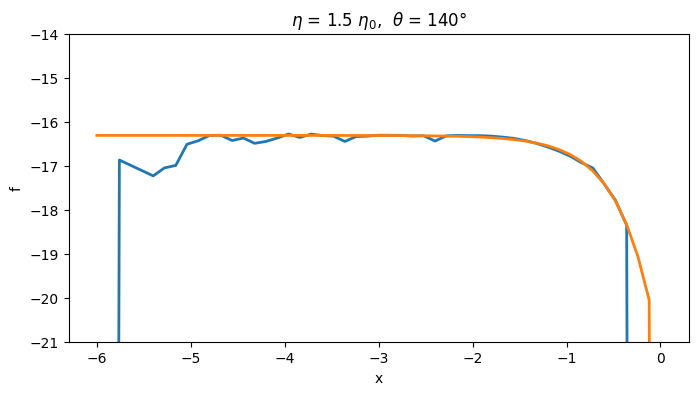

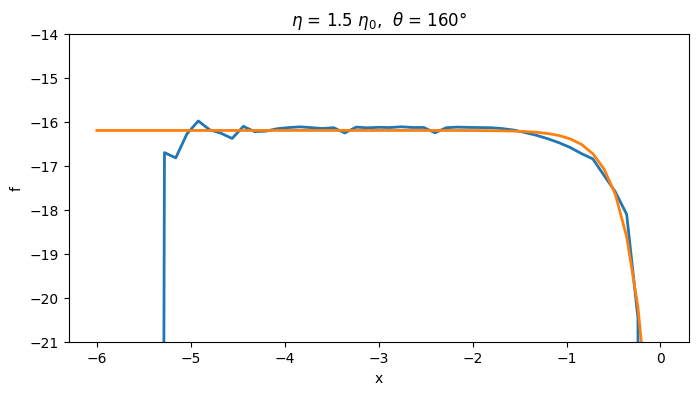

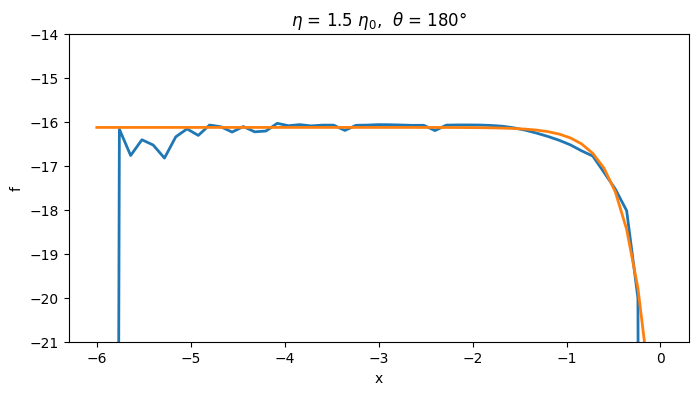

In [ ]:
eta_eta0 = 1.5
particle = "photon"
plot_fit_single(particle, eta_eta0, 120)
plot_fit_single(particle, eta_eta0 ,140)
plot_fit_single(particle, eta_eta0 ,160)
plot_fit_single(particle, eta_eta0 ,180)

[-16.93079861   0.51106092   0.58998767 -15.01183655  17.33461572]
[-16.61488816   0.51803748   0.56877917 -14.87664554  17.31968306]
[-16.78695363   0.51606776   0.56665021 -14.80937537  17.31812536]
[-17.71709328   0.50298367   0.59099787 -14.82007509  17.44657715]


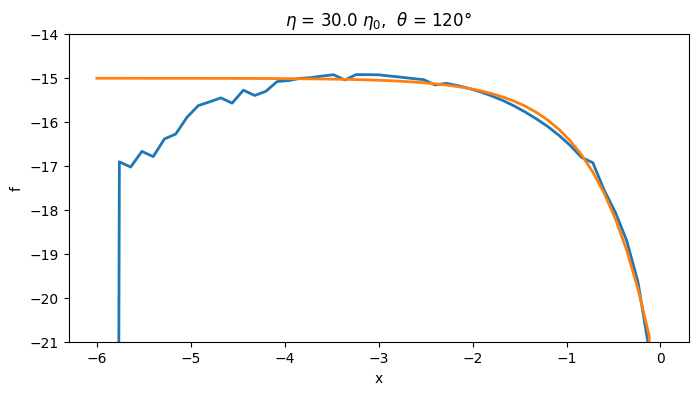

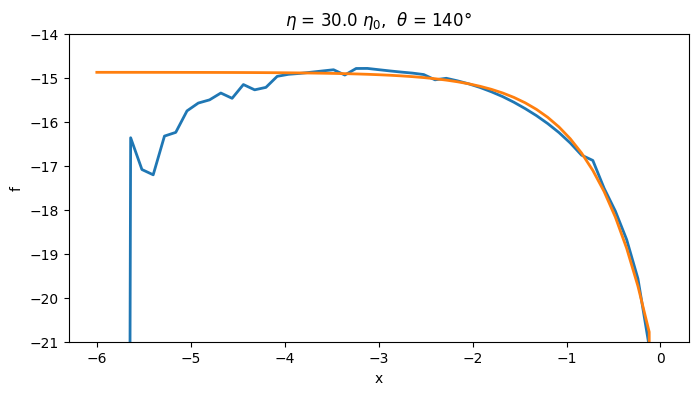

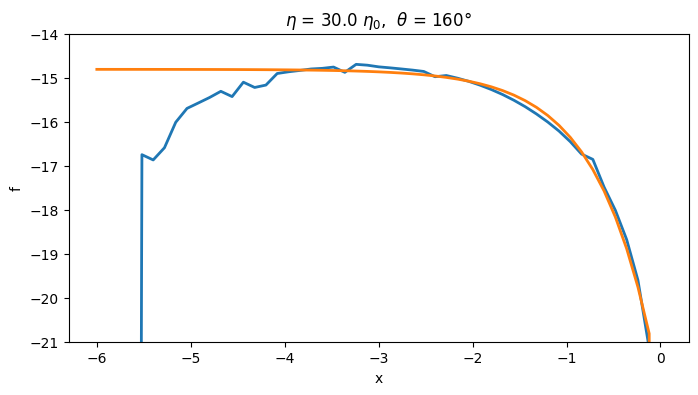

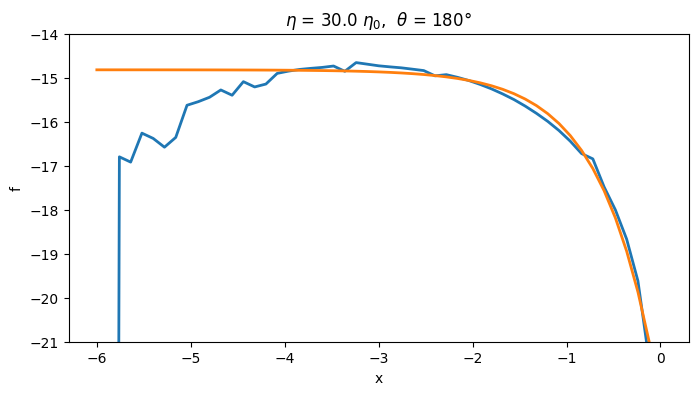

In [15]:
eta_eta0 = 30.0
particle = "photon"
plot_fit_single(particle, eta_eta0, 120)
plot_fit_single(particle, eta_eta0 ,140)
plot_fit_single(particle, eta_eta0 ,160)
plot_fit_single(particle, eta_eta0 ,180)

In [7]:
def fit_plot(particle):
    fig, ax = plt.subplots(22,19,figsize = (35, 20))

    fig.suptitle("Particle type: " + particle, fontsize=20)

    File = open(f"./integrand_values/Fx_{particle}.txt","w")

    print("#eta | theta | A | B | C | D    ||   F(x, A, B, C, D) = A*np.exp((x-B)*C)+D", file=File)

    i = 0
    for eta in _eta:
        j = 0
        for theta in range(0,190,10):
            interp_file = (
                f"./integrand_values/{particle}/{particle}_{eta}eta0_{theta}theta.txt"
            )

            x_i, spectrum = np.genfromtxt(
                interp_file, dtype="float", comments="#", usecols=(0, 1), unpack="True"
            )
            if(np.any(spectrum) == True):
                x_i = np.log10(np.where(x_i>0,x_i,1e-100))
                spectrum = np.log10(np.where(spectrum>0,spectrum,1e-100))

                ax[i,j].plot(x_i,spectrum,lw=2,label=r"SOPHIA")

                mask = (x_i >= -3) & (x_i <= 0)

                x_fit = x_i[mask]
                y_fit = spectrum[mask]

                count = 0
                for ii in range(0,6):
                    if(y_fit[len(y_fit)-ii-1] < -50.):
                        count=count+1
                if count!=0:
                    x_fit = x_fit[:-count]
                    y_fit = y_fit[:-count]

                # popt, pcov = curve_fit(F, x_fit, y_fit, bounds=([-40,0.1,0.1,-40.],
                #                                                 [-12,5.6,4.5,-12.]))
                # popt, pcov = curve_fit(F, x_fit, y_fit, bounds=([-40,0.1,0.1,-40.,4],
                #                                                 [-12,5.6,4.5,-12.,6]))
                # popt, pcov = curve_fit(F, x_fit, y_fit, bounds=([-40,0.1,0.1,-40.,10],
                #                                                 [-12,3.6,4.5,-12.,15]))
                popt, pcov = curve_fit(F, x_fit, y_fit, bounds=([-40,0.1,0.1,-40.,17],
                                                                [-12,0.6,4.5,-12.,20]))

                F_i = np.append(F(x_i, *popt),-100.)
                x_i = np.append(x_i,0.)

                # print(*popt, x_i[-2], file=File)
                print(eta,theta,*popt, file=File)

                ax[i,j].plot(x_i, F_i, lw=2, label=r"Fit")

                ax[i,j].set_xlim(-5,0)
                ax[i,j].set_ylim(-21,-14)
            else:
                print(eta,theta, -100., 0., 0., -100., 0., file=File)

            if i==0:
                ax[0,j].set_title(str(theta)+r"$\degree$")

            j = j+1
        
        ax[i,0].set_ylabel(eta+r" $\eta_{0}$")
        i=i+1

    File.close()


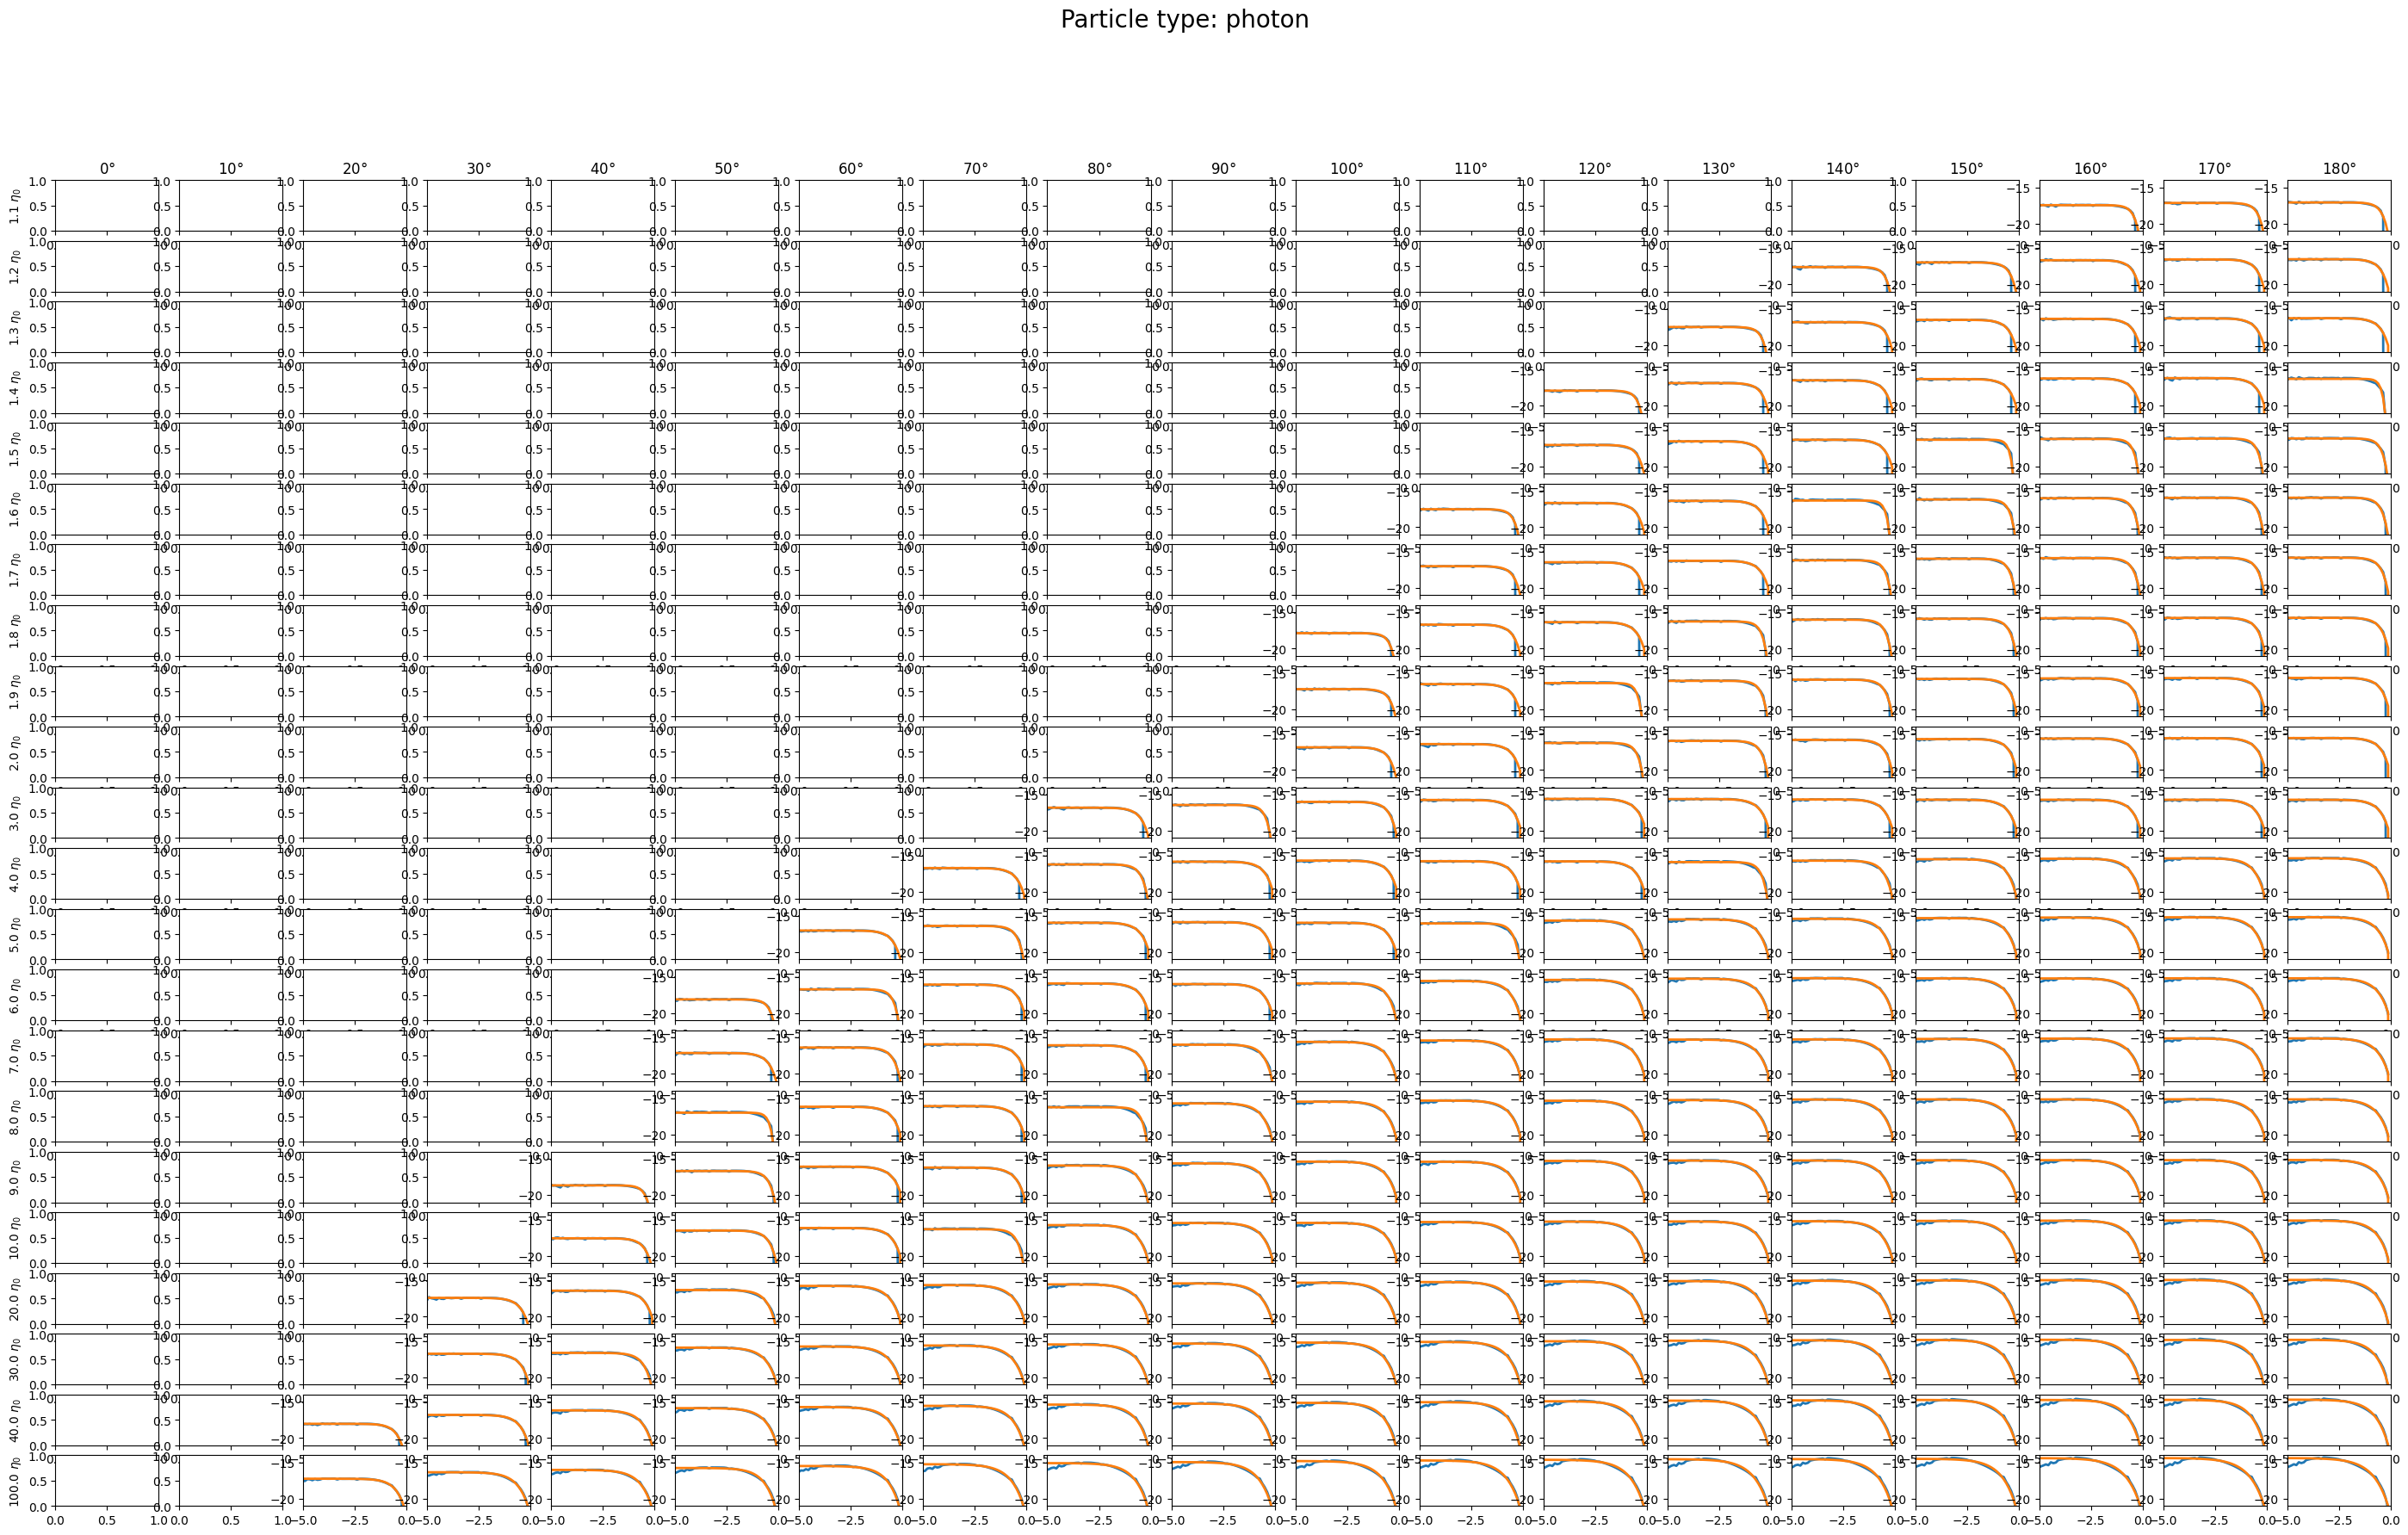

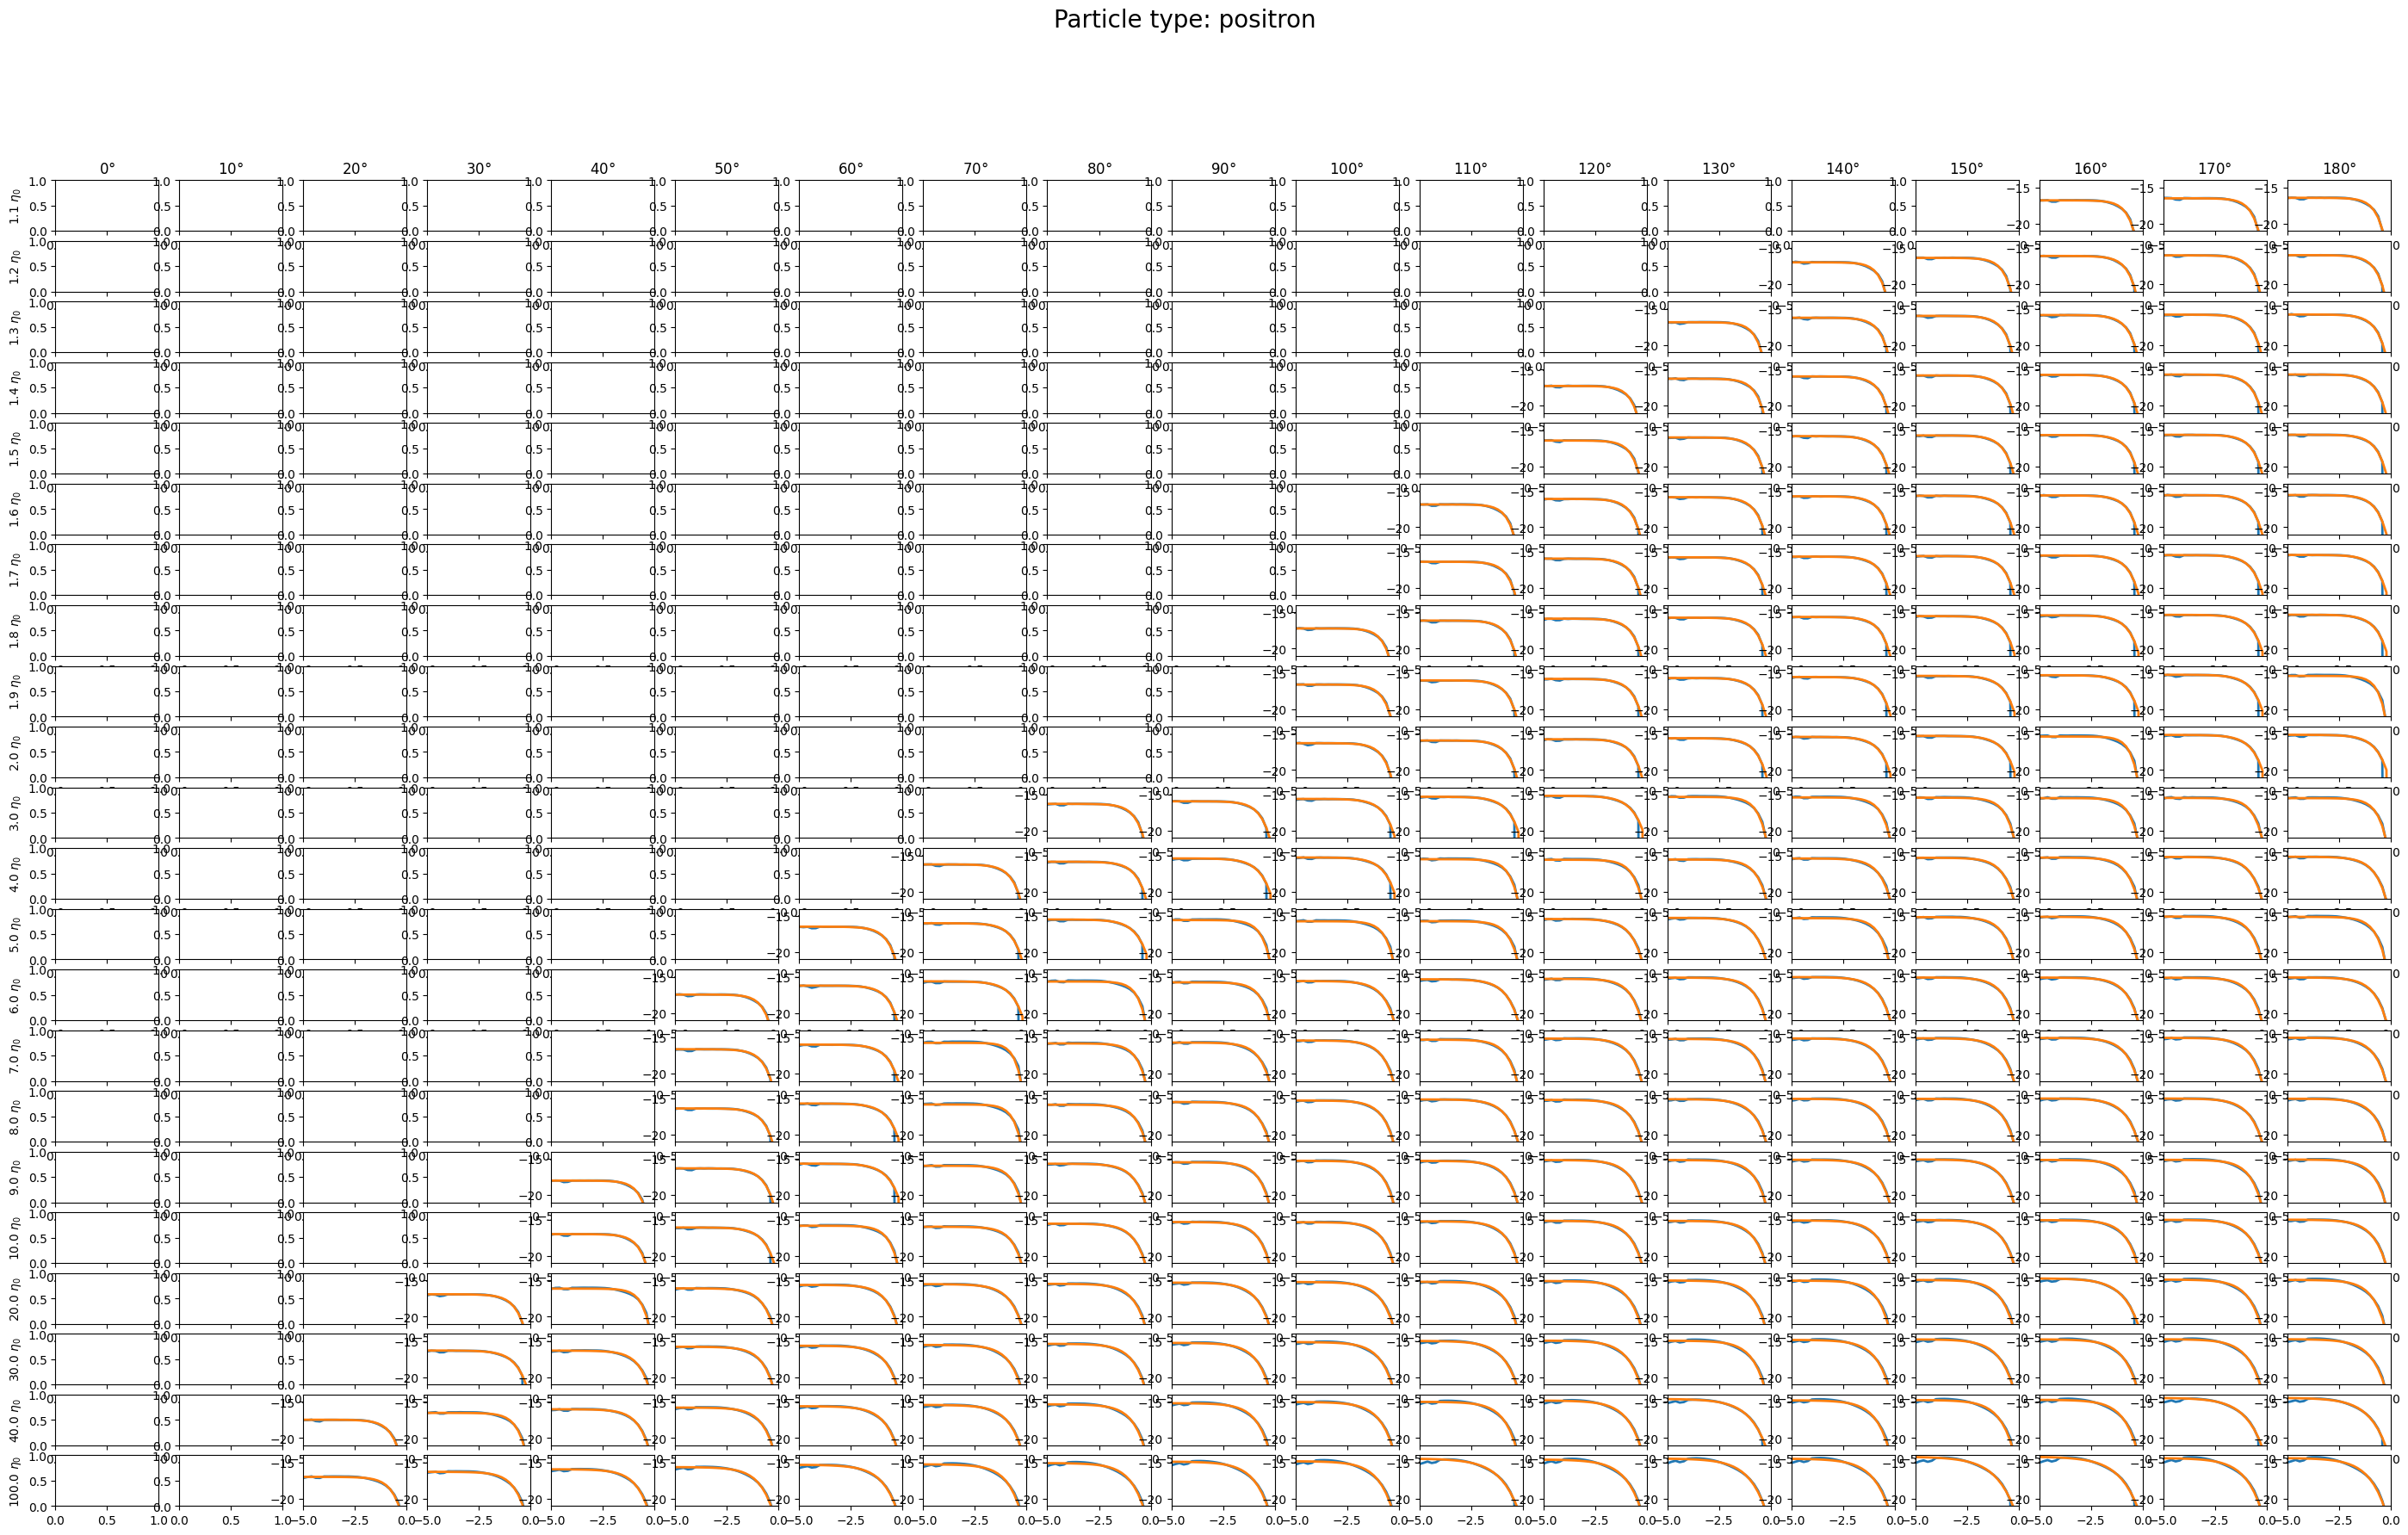

In [8]:
fit_plot("photon")
# fit_plot("electron")
fit_plot("positron")
# fit_plot("electron_neutrino")
# fit_plot("electron_antineutrino")
# fit_plot("muon_neutrino")
# fit_plot("muon_antineutrino")

In [9]:
# particle = "photon"
# data = np.loadtxt(f"./integrand_values/Fx_{particle}.txt")

# eta = data[:, 0]
# theta = data[:, 1]
# params = data[:, 2:]

# points = np.column_stack((eta, theta))

# # interp = LinearNDInterpolator(points, params)
# linear = LinearNDInterpolator(points, params)
# nearest = NearestNDInterpolator(points, params)

# def interp(eta, theta):
#     val = linear(eta, theta)
#     mask = np.isnan(val)
    
#     if np.any(mask):
#         val[mask] = nearest(eta, theta)[mask]
    
#     return val

# result = interp(40, 10)
# print(result)

# result = interp(40, 20)/2.
# print(result)

In [10]:
class Fx:
    def __init__(self, particle):
        data = np.loadtxt(f"./integrand_values/Fx_{particle}.txt")

        eta = data[:, 0]
        theta = data[:, 1]
        params = data[:, 2:]

        points = np.column_stack((eta*eta_0, theta))

        self.linear = LinearNDInterpolator(points, params)
        self.nearest = NearestNDInterpolator(points, params)

    def interp(self, eta, theta):
        pts = np.column_stack((np.atleast_1d(eta), np.atleast_1d(theta)))

        val = self.linear(pts)
        mask = np.isnan(val)

        if np.any(mask):
            val[mask] = self.nearest(pts)[mask]

        return val.squeeze()
    
    def F(self, x, A, B, C, D, E):
        return 10**(A*np.pow(E,(x-B)*C)+D)
    
    def __call__(self, x, eta, theta):
        A, B, C, D, E = self.interp(eta, theta)
        return np.where(x<0.99,self.F(np.log10(x), A, B, C, D, E),0.)

In [22]:
def part_label(particle):
    if particle == "photon":
        return r"\gamma"
    if particle == "positron":
        return r"e^{+}"
    if particle == "muon_antineutrino":
        return r"\bar{\nu}_{\mu}"
    if particle == "muon_neutrino":
        return r"\nu_{\mu}"

def plot_Phi(particle, eta_eta0):
    _x = np.logspace(-5,0,100)
    FF = Fx("photon")
    Y = []

    for xi in _x:

        theta = np.linspace(0., 180., 18*4)
        vals = np.array([FF(xi, eta_eta0*eta_0, thetai)*np.sin(thetai*np.pi/180.) for thetai in theta])
        result = np.trapezoid(vals, theta)/2.*np.pi/180.
        Y.append(result*xi)

    # print(Y)

    fig, ax = plt.subplots(1,1,figsize = (8, 4))

    fig.suptitle(rf"Particle type: {particle},  $\eta$ = {eta_eta0} $\eta_{0}$")

    interp_file = (f"./kelner_aharonian_2008/fig2_values/gamma_{eta_eta0}eta0.txt")

    x_i, spectrum = np.genfromtxt(
        interp_file, dtype="float", comments="#", usecols=(0, 1), unpack="True"
    )

    x_i = np.power(10,x_i)
    spectrum = np.power(10,spectrum)

    ax.loglog(x_i,spectrum,lw=5,label=r"K&A")

    ax.loglog(_x,Y)
    
    ax.set_xlabel(rf"x = E$_{{{part_label(particle)}}}$ / E$_p$")
    ax.set_ylabel(rf"x $\phi_{{{part_label(particle)}}}$($\eta$,x)")

    if(eta_eta0 == 1.5):
        ax.set_xlim(1e-4,1e0)
        ax.set_ylim(1e-21,1e-18)
    if(eta_eta0 == 30):
        ax.set_xlim(1e-4,1e0)
        ax.set_ylim(1e-20,1e-17)

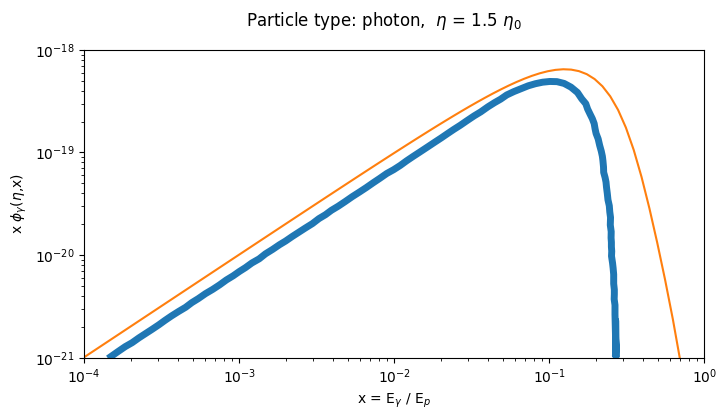

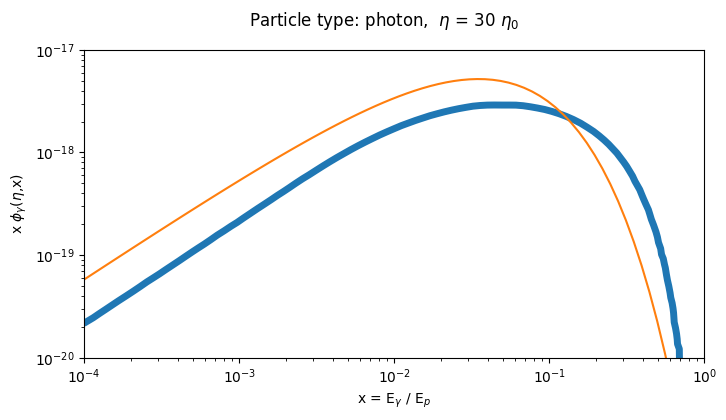

In [23]:
particle = "photon"
plot_Phi(particle,1.5)
plot_Phi(particle,30)

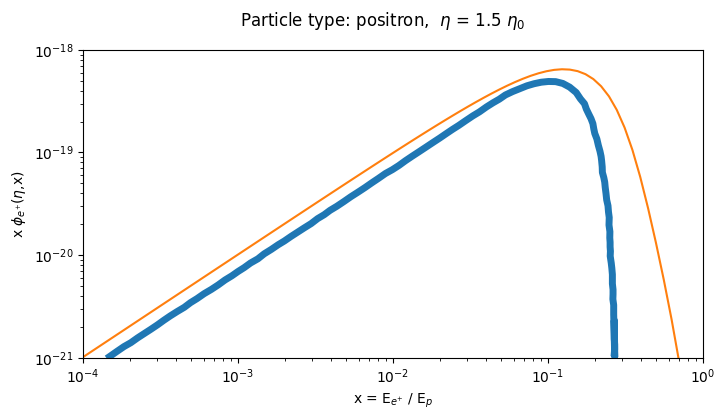

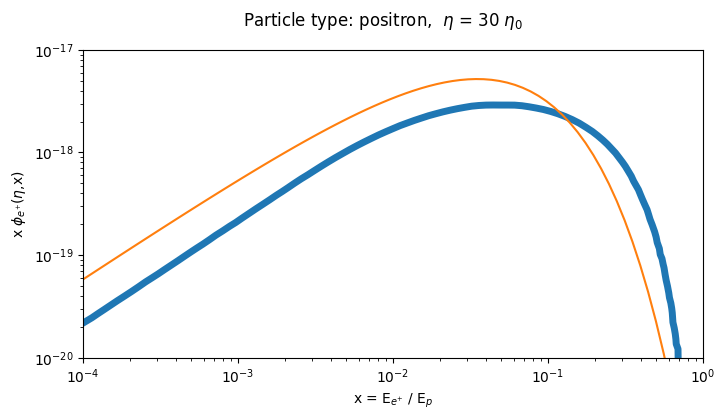

In [24]:
particle = "positron"
plot_Phi(particle,1.5)
plot_Phi(particle,30)